# Task 1: Term Deposit Subscription Prediction

## DevelopersHub Corporation - Data Science & Analytics Internship

### Objective:
Predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign.

### Dataset:
Bank Marketing Dataset (UCI Machine Learning Repository)

### Models Used:
- Logistic Regression
- Random Forest Classifier

### Evaluation Metrics:
- Confusion Matrix
- F1-Score
- ROC Curve
- SHAP (Explainable AI)

### Tools Used:
Python 3.10, pandas, numpy, matplotlib, seaborn, scikit-learn, shap

In [3]:
# Install all required libraries for this task
import subprocess
import sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])
print("shap installed!")

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])
print("xgboost installed!")

shap installed!
xgboost installed!


In [4]:
# ============================================================
# Step 1: Import All Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score,
                             roc_curve, roc_auc_score)

# Explainable AI
import shap

import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")

c:\Users\home computers\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully!


In [8]:
# ============================================================
# Step 2: Load the Bank Marketing Dataset
# ============================================================

df = pd.read_csv('bank.csv')

print("Dataset loaded successfully!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset loaded successfully!
Total Rows: 11162
Total Columns: 17


In [9]:
# ============================================================
# Step 3: First Look at the Dataset
# ============================================================

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [10]:
# ============================================================
# Step 4: Dataset Structure and Information
# ============================================================

print("Dataset Shape:", df.shape)
print()

print("Column Names and Data Types:")
print("-" * 45)
for col in df.columns:
    print(f"  {col:20s} -> {df[col].dtype}")
print()

print("Statistical Summary:")
df.describe()

Dataset Shape: (11162, 17)

Column Names and Data Types:
---------------------------------------------
  age                  -> int64
  job                  -> object
  marital              -> object
  education            -> object
  default              -> object
  balance              -> int64
  housing              -> object
  loan                 -> object
  contact              -> object
  day                  -> int64
  month                -> object
  duration             -> int64
  campaign             -> int64
  pdays                -> int64
  previous             -> int64
  poutcome             -> object
  deposit              -> object

Statistical Summary:


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [11]:
# ============================================================
# Step 5: Check for Missing Values
# ============================================================

print("Missing Values in Each Column:")
print("=" * 45)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

if df.isnull().sum().sum() == 0:
    print("\nNo missing values! Dataset is clean.")

Missing Values in Each Column:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total Missing Values: 0

No missing values! Dataset is clean.


In [12]:
# ============================================================
# Step 6: Unique Values in Each Column
# ============================================================

print("Unique Values in Each Column:")
print("=" * 45)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].dtype == 'object':
        print(f"   Values: {df[col].unique()}")
    print()

Unique Values in Each Column:
age: 76 unique values

job: 12 unique values
   Values: ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']

marital: 3 unique values
   Values: ['married' 'single' 'divorced']

education: 4 unique values
   Values: ['secondary' 'tertiary' 'primary' 'unknown']

default: 2 unique values
   Values: ['no' 'yes']

balance: 3805 unique values

housing: 2 unique values
   Values: ['yes' 'no']

loan: 2 unique values
   Values: ['no' 'yes']

contact: 3 unique values
   Values: ['unknown' 'cellular' 'telephone']

day: 31 unique values

month: 12 unique values
   Values: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

duration: 1428 unique values

campaign: 36 unique values

pdays: 472 unique values

previous: 34 unique values

poutcome: 4 unique values
   Values: ['unknown' 'other' 'failure' 'success']

deposit: 2 unique values
   Values: ['y

## Exploratory Data Analysis (EDA)

Analyzing key features to understand customer subscription patterns:
1. Target Variable Distribution (deposit)
2. Age Distribution
3. Job vs Subscription
4. Marital Status vs Subscription
5. Education vs Subscription
6. Balance Analysis
7. Contact Duration Analysis
8. Correlation Heatmap

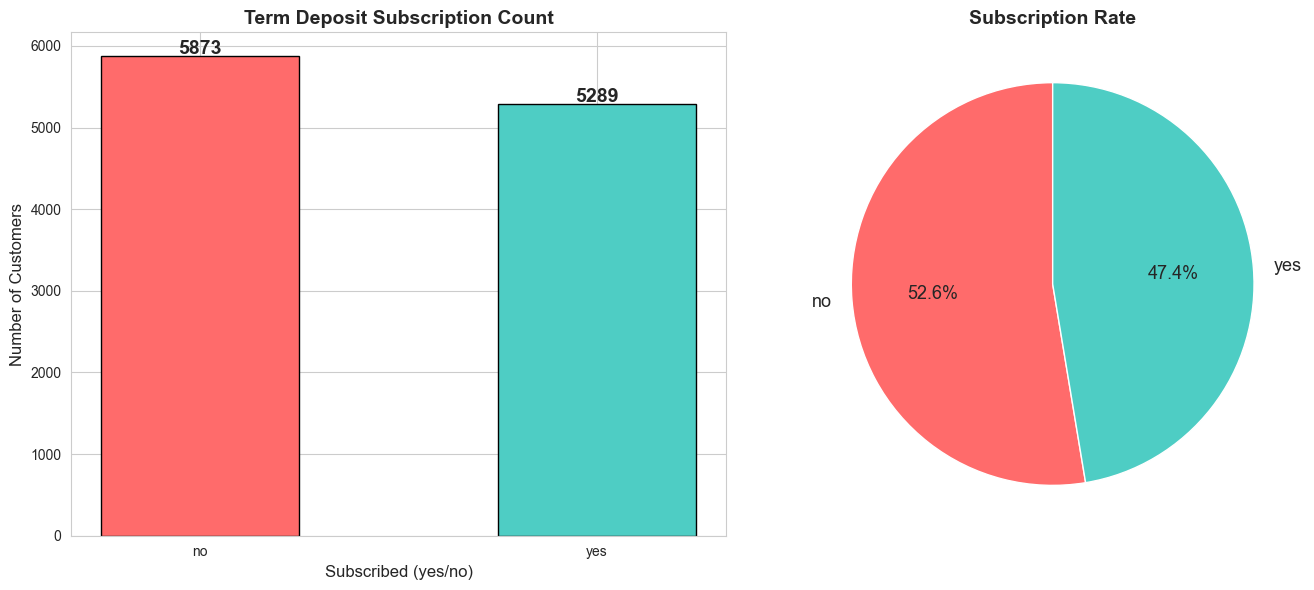

Subscribed (yes): 5289 (47.4%)
Not Subscribed (no): 5873 (52.6%)


In [13]:
# ============================================================
# Step 7: Target Variable Distribution
# ============================================================
# 'deposit' = yes means customer subscribed to term deposit

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart
counts = df['deposit'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']

bars = axes[0].bar(counts.index, counts.values,
                   color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 str(val), ha='center',
                 fontsize=14, fontweight='bold')
axes[0].set_title('Term Deposit Subscription Count',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Subscribed (yes/no)', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)

# Pie Chart
axes[1].pie(counts.values, labels=counts.index,
            colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Subscription Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Subscribed (yes): {counts['yes']} ({counts['yes']/len(df)*100:.1f}%)")
print(f"Not Subscribed (no): {counts['no']} ({counts['no']/len(df)*100:.1f}%)")

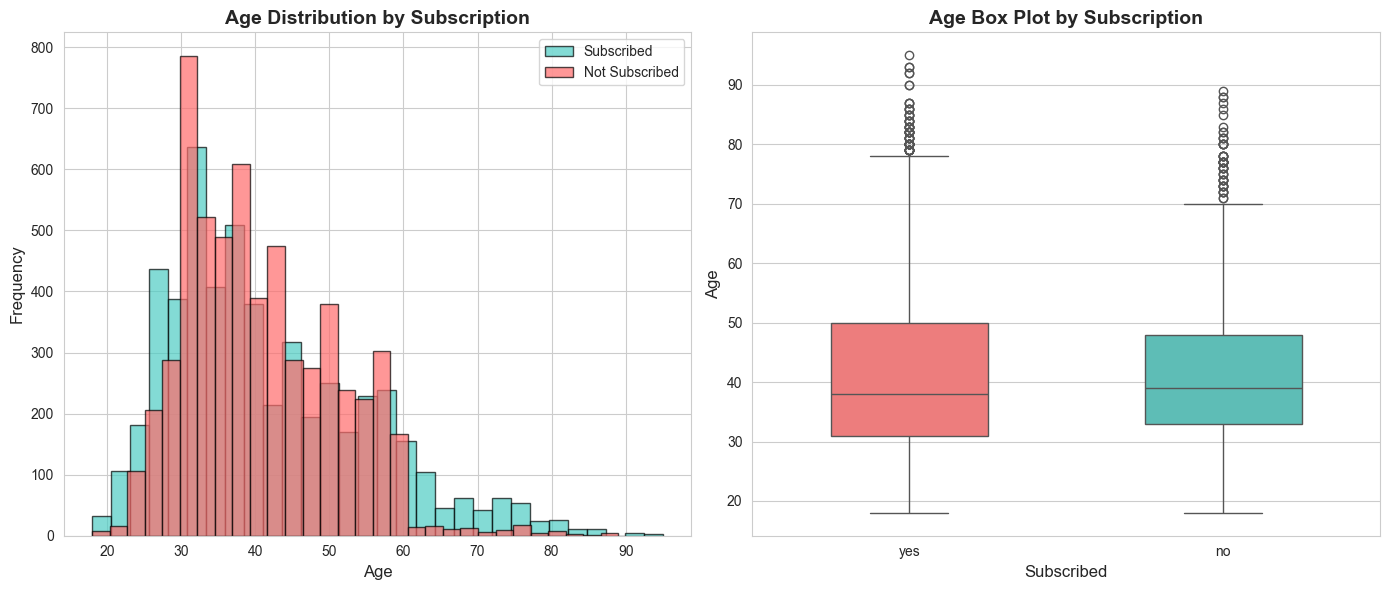

Average age - Subscribed: 41.7
Average age - Not Subscribed: 40.8


In [14]:
# ============================================================
# Step 8: Age Distribution by Subscription Status
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
df[df['deposit'] == 'yes']['age'].hist(
    bins=30, ax=axes[0], alpha=0.7,
    color='#4ECDC4', edgecolor='black', label='Subscribed')
df[df['deposit'] == 'no']['age'].hist(
    bins=30, ax=axes[0], alpha=0.7,
    color='#FF6B6B', edgecolor='black', label='Not Subscribed')
axes[0].set_title('Age Distribution by Subscription',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()

# Box Plot
sns.boxplot(data=df, x='deposit', y='age',
            palette=['#FF6B6B', '#4ECDC4'],
            width=0.5, ax=axes[1])
axes[1].set_title('Age Box Plot by Subscription',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Subscribed', fontsize=12)
axes[1].set_ylabel('Age', fontsize=12)

plt.tight_layout()
plt.show()

yes_age = df[df['deposit'] == 'yes']['age'].mean()
no_age = df[df['deposit'] == 'no']['age'].mean()
print(f"Average age - Subscribed: {yes_age:.1f}")
print(f"Average age - Not Subscribed: {no_age:.1f}")

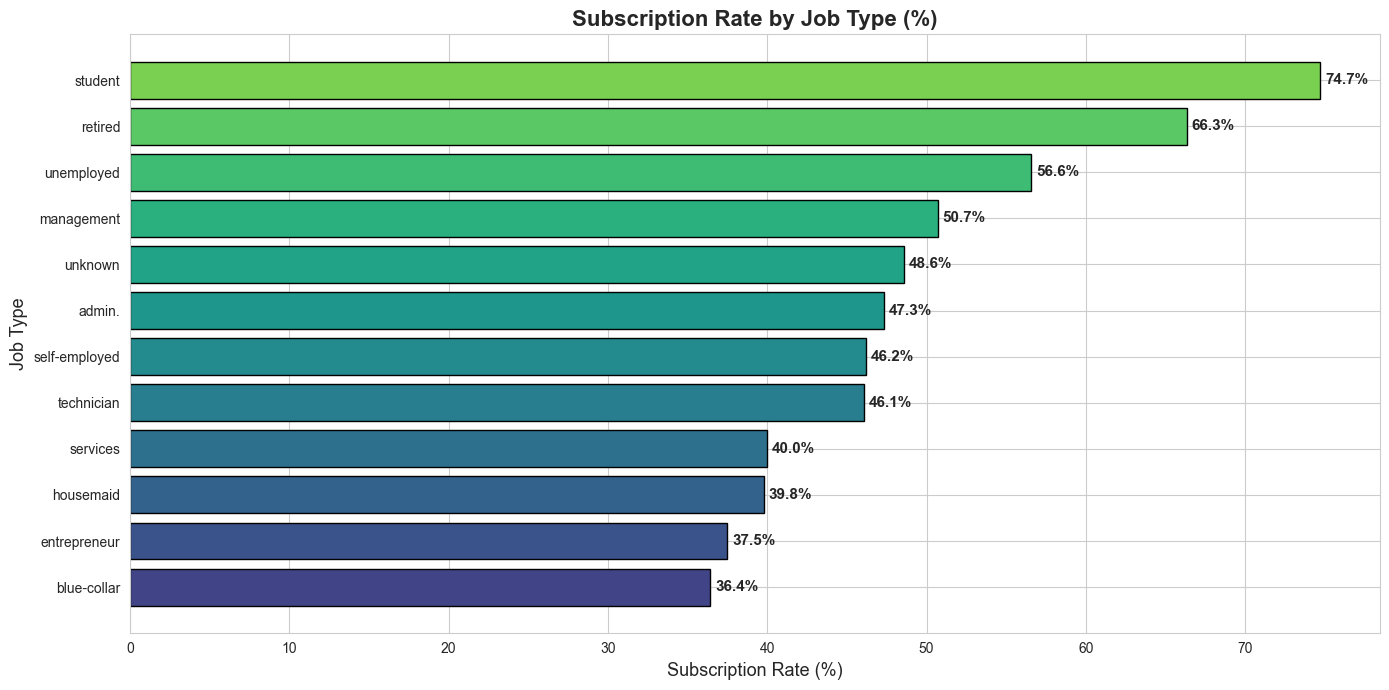

Top 3 Jobs with Highest Subscription Rate:
  unemployed: 56.6%
  retired: 66.3%
  student: 74.7%


In [15]:
# ============================================================
# Step 9: Job Type vs Subscription Rate
# ============================================================

plt.figure(figsize=(14, 7))

# Calculate subscription rate by job
sub_rate_by_job = df.groupby('job')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).sort_values(ascending=True)

colors = plt.cm.viridis(
    np.linspace(0.2, 0.8, len(sub_rate_by_job))
)
bars = plt.barh(sub_rate_by_job.index,
                sub_rate_by_job.values,
                color=colors, edgecolor='black')

# Add percentage labels
for bar, val in zip(bars, sub_rate_by_job.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center',
             fontsize=11, fontweight='bold')

plt.title('Subscription Rate by Job Type (%)',
          fontsize=16, fontweight='bold')
plt.xlabel('Subscription Rate (%)', fontsize=13)
plt.ylabel('Job Type', fontsize=13)
plt.tight_layout()
plt.show()

print("Top 3 Jobs with Highest Subscription Rate:")
for job, rate in sub_rate_by_job.tail(3).items():
    print(f"  {job}: {rate:.1f}%")

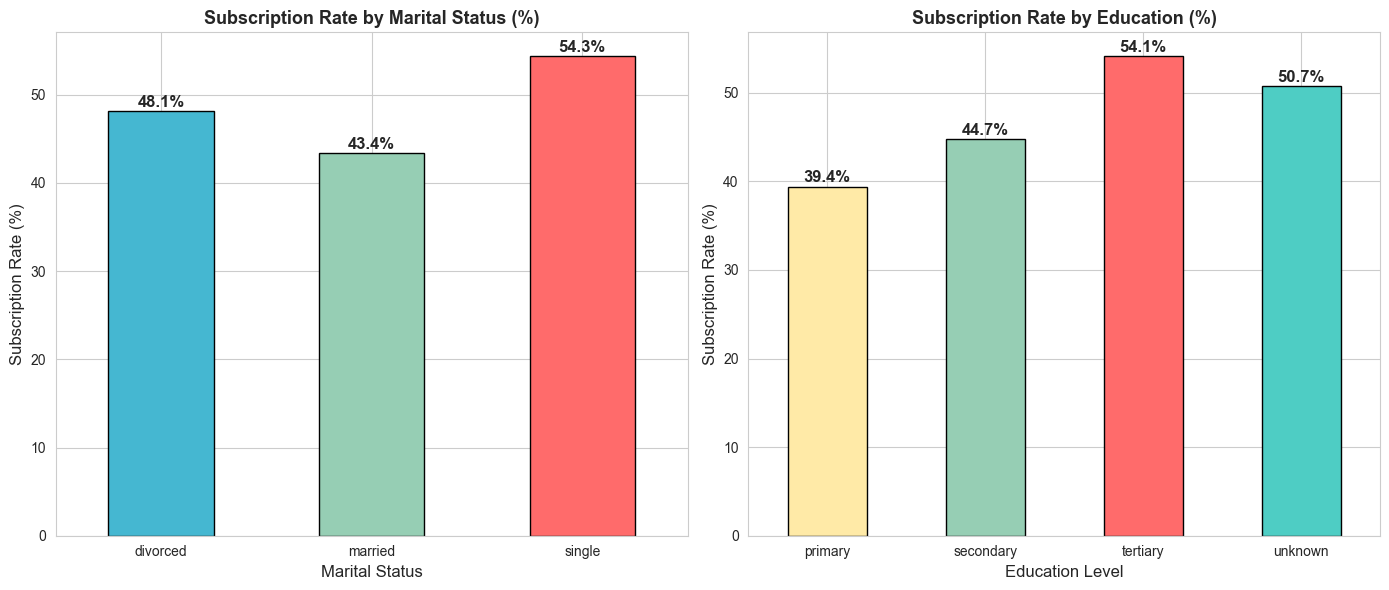

In [16]:
# ============================================================
# Step 10: Marital Status and Education vs Subscription
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Marital Status
sub_by_marital = df.groupby('marital')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
)
sub_by_marital.plot(kind='bar', ax=axes[0],
    color=['#45B7D1', '#96CEB4', '#FF6B6B'],
    edgecolor='black')
axes[0].set_title('Subscription Rate by Marital Status (%)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Marital Status', fontsize=12)
axes[0].set_ylabel('Subscription Rate (%)', fontsize=12)
axes[0].set_xticklabels(
    axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(sub_by_marital.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%',
                 ha='center', fontsize=12, fontweight='bold')

# Education
sub_by_edu = df.groupby('education')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
)
sub_by_edu.plot(kind='bar', ax=axes[1],
    color=['#FFEAA7', '#96CEB4', '#FF6B6B', '#4ECDC4'],
    edgecolor='black')
axes[1].set_title('Subscription Rate by Education (%)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Education Level', fontsize=12)
axes[1].set_ylabel('Subscription Rate (%)', fontsize=12)
axes[1].set_xticklabels(
    axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(sub_by_edu.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%',
                 ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

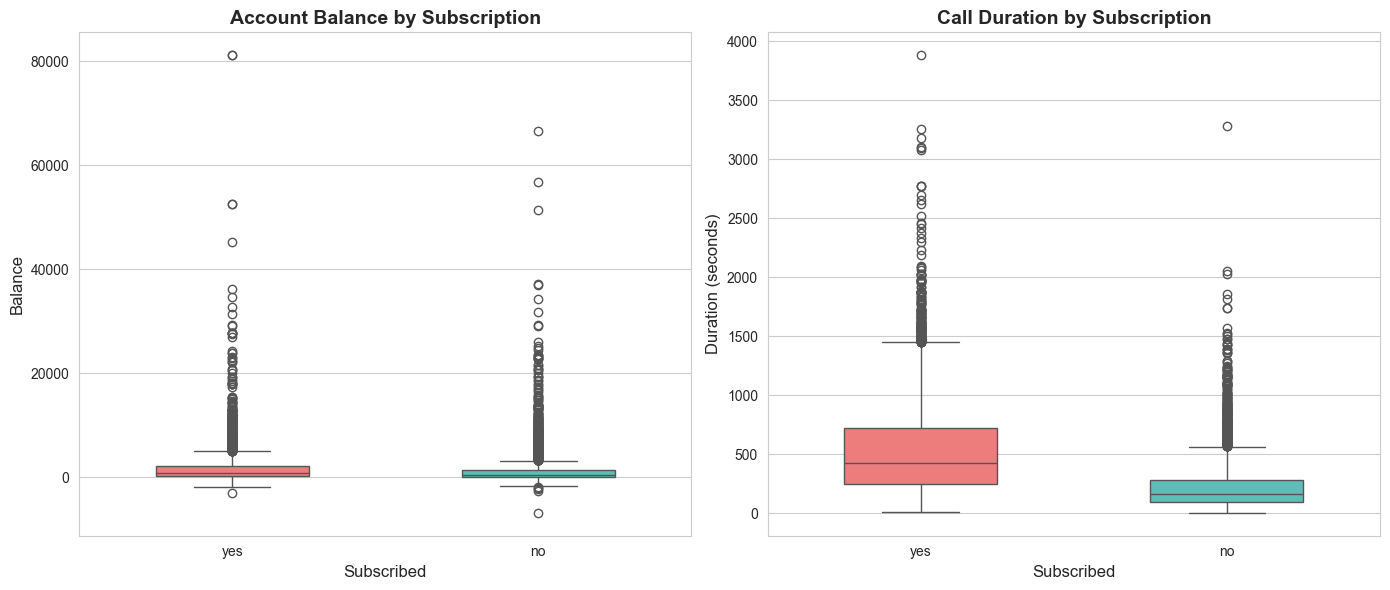

Average Balance:
  Subscribed: $1804
  Not Subscribed: $1280

Average Call Duration:
  Subscribed: 537 seconds
  Not Subscribed: 223 seconds

Observation: Longer calls are strongly associated with subscription!


In [17]:
# ============================================================
# Step 11: Balance and Call Duration Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Balance Box Plot
sns.boxplot(data=df, x='deposit', y='balance',
            palette=['#FF6B6B', '#4ECDC4'],
            width=0.5, ax=axes[0])
axes[0].set_title('Account Balance by Subscription',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Subscribed', fontsize=12)
axes[0].set_ylabel('Balance', fontsize=12)

# Duration Box Plot
sns.boxplot(data=df, x='deposit', y='duration',
            palette=['#FF6B6B', '#4ECDC4'],
            width=0.5, ax=axes[1])
axes[1].set_title('Call Duration by Subscription',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Subscribed', fontsize=12)
axes[1].set_ylabel('Duration (seconds)', fontsize=12)

plt.tight_layout()
plt.show()

print("Average Balance:")
print(f"  Subscribed: ${df[df['deposit']=='yes']['balance'].mean():.0f}")
print(f"  Not Subscribed: ${df[df['deposit']=='no']['balance'].mean():.0f}")
print()
print("Average Call Duration:")
print(f"  Subscribed: {df[df['deposit']=='yes']['duration'].mean():.0f} seconds")
print(f"  Not Subscribed: {df[df['deposit']=='no']['duration'].mean():.0f} seconds")
print()
print("Observation: Longer calls are strongly associated with subscription!")

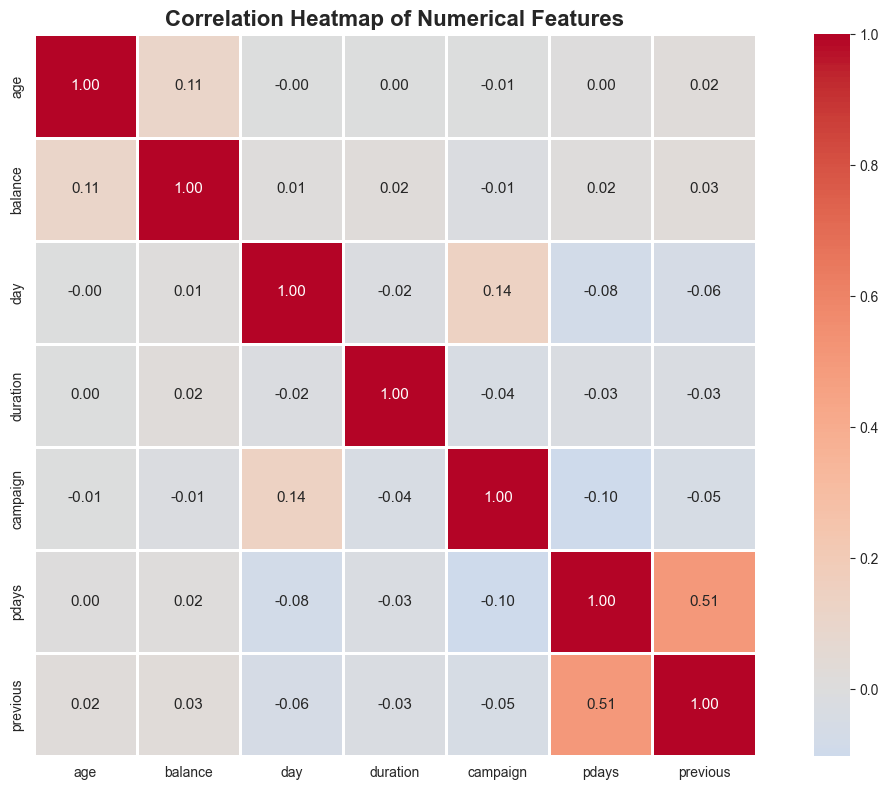

In [19]:
# ============================================================
# Step 12: Correlation Heatmap
# ============================================================

plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include='number')
correlation = numeric_df.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm',
            center=0, square=True, linewidths=1,
            fmt='.2f', annot_kws={'fontsize': 11})

plt.title('Correlation Heatmap of Numerical Features',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Building

### Steps:
1. Encode all categorical variables using Label Encoding
2. Scale numerical features using StandardScaler
3. Split data: 80% training, 20% testing
4. Train Logistic Regression model
5. Train Random Forest model
6. Evaluate using Confusion Matrix, F1-Score, ROC Curve
7. Use SHAP to explain model predictions

In [20]:
# ============================================================
# Step 13: Encode All Categorical Variables
# ============================================================

df_model = df.copy()

# Use Label Encoder for all categorical columns
le = LabelEncoder()

categorical_cols = df_model.select_dtypes(include='object').columns
print("Encoding Categorical Columns:")
print("-" * 40)

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"  {col}: Encoded successfully")

print()
print("First 5 rows after encoding:")
df_model.head()

Encoding Categorical Columns:
----------------------------------------
  job: Encoded successfully
  marital: Encoded successfully
  education: Encoded successfully
  default: Encoded successfully
  housing: Encoded successfully
  loan: Encoded successfully
  contact: Encoded successfully
  month: Encoded successfully
  poutcome: Encoded successfully
  deposit: Encoded successfully

First 5 rows after encoding:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [21]:
# ============================================================
# Step 14: Define Features, Target and Split Data
# ============================================================

# Features (X) - all columns except 'deposit'
X = df_model.drop('deposit', axis=1)

# Target (y) - deposit column (1=yes, 0=no)
y = df_model['deposit']

# Scale features for better model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Data Split Complete!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Data Split Complete!
Training samples: 8929
Testing samples: 2233

Class distribution in training set:
deposit
0    4698
1    4231
Name: count, dtype: int64


In [22]:
# ============================================================
# Step 15: Train Logistic Regression Model
# ============================================================

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"\nAccuracy: {lr_accuracy * 100:.2f}%")
print(f"F1-Score: {lr_f1:.4f}")
print(f"ROC-AUC Score: {lr_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['Not Subscribed', 'Subscribed']))

LOGISTIC REGRESSION RESULTS

Accuracy: 79.76%
F1-Score: 0.7829
ROC-AUC Score: 0.8729

Classification Report:
                precision    recall  f1-score   support

Not Subscribed       0.80      0.82      0.81      1175
    Subscribed       0.80      0.77      0.78      1058

      accuracy                           0.80      2233
     macro avg       0.80      0.80      0.80      2233
  weighted avg       0.80      0.80      0.80      2233



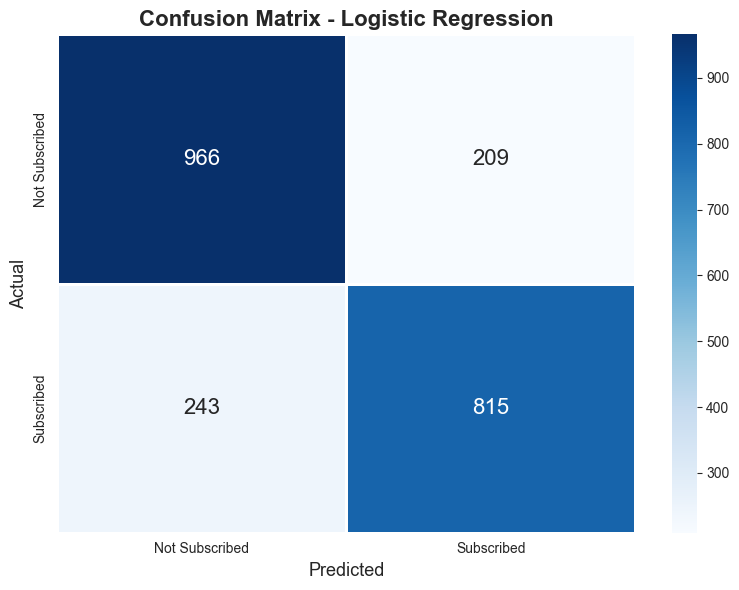

Confusion Matrix Breakdown:
  True Negatives  (Correctly Not Subscribed): 966
  False Positives (Wrongly Subscribed): 209
  False Negatives (Wrongly Not Subscribed): 243
  True Positives  (Correctly Subscribed): 815


In [23]:
# ============================================================
# Step 16: Confusion Matrix - Logistic Regression
# ============================================================

plt.figure(figsize=(8, 6))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Subscribed', 'Subscribed'],
            yticklabels=['Not Subscribed', 'Subscribed'],
            annot_kws={'fontsize': 16}, linewidths=2)

plt.title('Confusion Matrix - Logistic Regression',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.tight_layout()
plt.show()

print("Confusion Matrix Breakdown:")
print(f"  True Negatives  (Correctly Not Subscribed): {cm_lr[0][0]}")
print(f"  False Positives (Wrongly Subscribed): {cm_lr[0][1]}")
print(f"  False Negatives (Wrongly Not Subscribed): {cm_lr[1][0]}")
print(f"  True Positives  (Correctly Subscribed): {cm_lr[1][1]}")

In [24]:
# ============================================================
# Step 17: Train Random Forest Classifier
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42,
    max_depth=10, n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"\nAccuracy: {rf_accuracy * 100:.2f}%")
print(f"F1-Score: {rf_f1:.4f}")
print(f"ROC-AUC Score: {rf_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['Not Subscribed', 'Subscribed']))

RANDOM FOREST RESULTS

Accuracy: 84.01%
F1-Score: 0.8359
ROC-AUC Score: 0.9127

Classification Report:
                precision    recall  f1-score   support

Not Subscribed       0.87      0.82      0.84      1175
    Subscribed       0.81      0.86      0.84      1058

      accuracy                           0.84      2233
     macro avg       0.84      0.84      0.84      2233
  weighted avg       0.84      0.84      0.84      2233



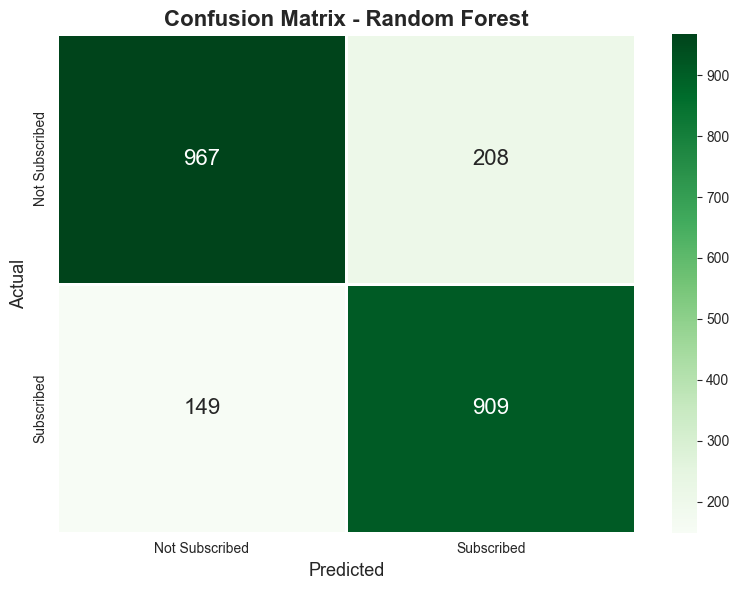

In [25]:
# ============================================================
# Step 18: Confusion Matrix - Random Forest
# ============================================================

plt.figure(figsize=(8, 6))

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Subscribed', 'Subscribed'],
            yticklabels=['Not Subscribed', 'Subscribed'],
            annot_kws={'fontsize': 16}, linewidths=2)

plt.title('Confusion Matrix - Random Forest',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.tight_layout()
plt.show()

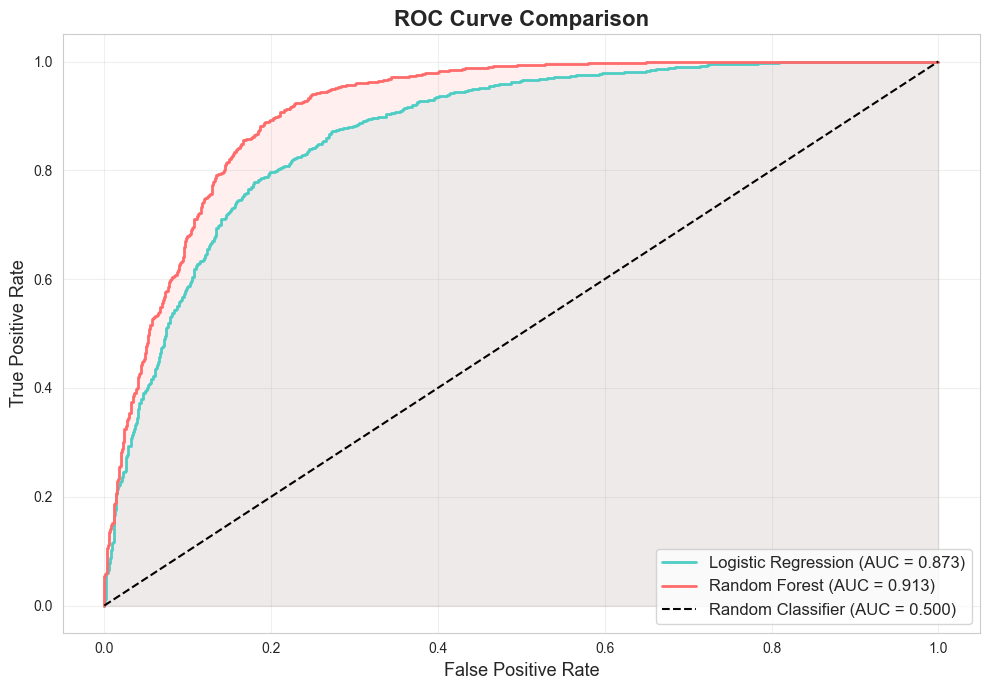

ROC-AUC Scores:
  Logistic Regression: 0.8729
  Random Forest: 0.9127

Random Forest has better ROC-AUC Score!


In [26]:
# ============================================================
# Step 19: ROC Curve Comparison - Both Models
# ============================================================
# ROC Curve shows how well model distinguishes between classes
# AUC closer to 1.0 = better model

plt.figure(figsize=(10, 7))

# Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
plt.plot(lr_fpr, lr_tpr, color='#4ECDC4', linewidth=2,
         label=f'Logistic Regression (AUC = {lr_auc:.3f})')

# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(rf_fpr, rf_tpr, color='#FF6B6B', linewidth=2,
         label=f'Random Forest (AUC = {rf_auc:.3f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5,
         label='Random Classifier (AUC = 0.500)')

plt.fill_between(lr_fpr, lr_tpr, alpha=0.1, color='#4ECDC4')
plt.fill_between(rf_fpr, rf_tpr, alpha=0.1, color='#FF6B6B')

plt.title('ROC Curve Comparison', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC-AUC Scores:")
print(f"  Logistic Regression: {lr_auc:.4f}")
print(f"  Random Forest: {rf_auc:.4f}")
print()
if rf_auc > lr_auc:
    print("Random Forest has better ROC-AUC Score!")
else:
    print("Logistic Regression has better ROC-AUC Score!")

FINAL MODEL COMPARISON
Metric                  Logistic Reg   Random Forest
-------------------------------------------------------
Accuracy                      79.76%          84.01%
F1-Score                      0.7829          0.8359
ROC-AUC                       0.8729          0.9127


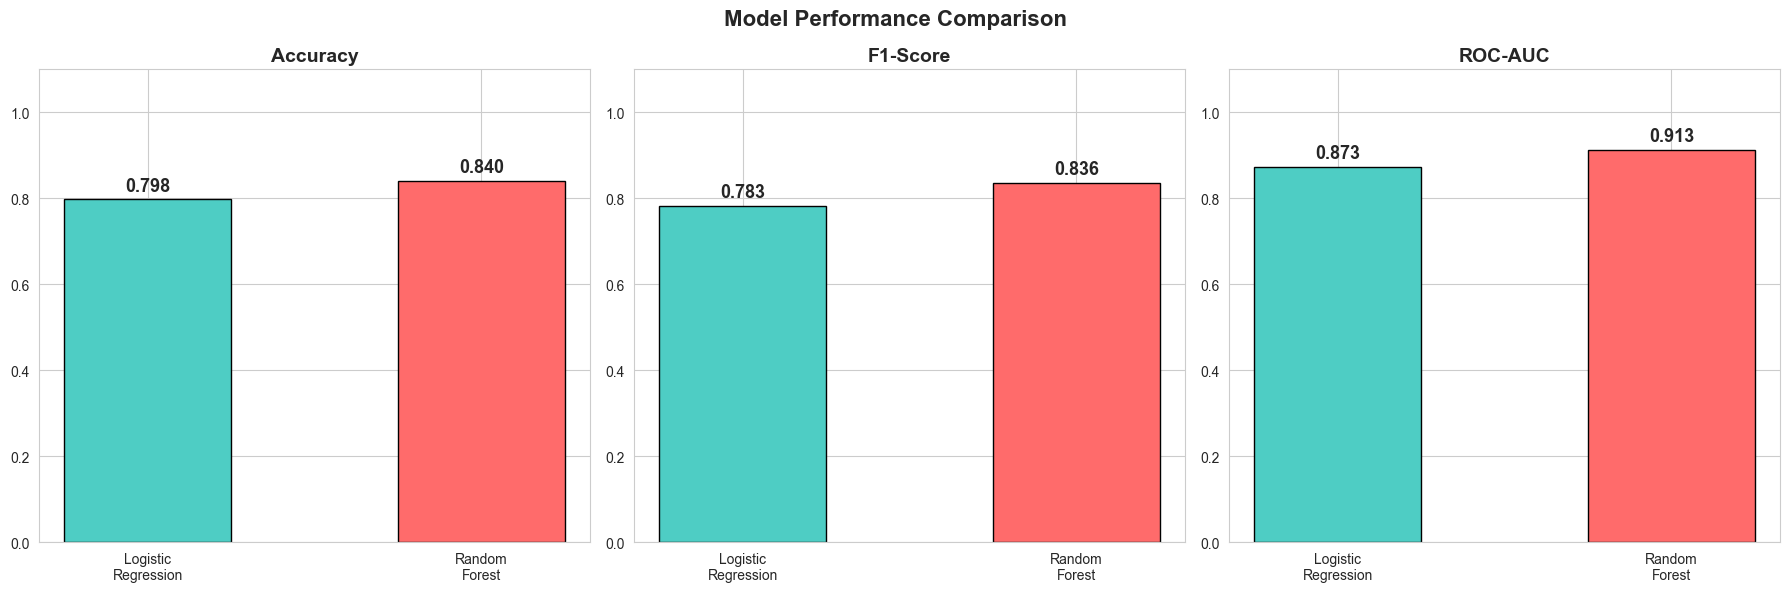

In [27]:
# ============================================================
# Step 20: Model Performance Comparison
# ============================================================

print("=" * 55)
print("FINAL MODEL COMPARISON")
print("=" * 55)
print(f"{'Metric':<20} {'Logistic Reg':>15} {'Random Forest':>15}")
print("-" * 55)
print(f"{'Accuracy':<20} {lr_accuracy*100:>14.2f}% {rf_accuracy*100:>14.2f}%")
print(f"{'F1-Score':<20} {lr_f1:>15.4f} {rf_f1:>15.4f}")
print(f"{'ROC-AUC':<20} {lr_auc:>15.4f} {rf_auc:>15.4f}")

# Visual Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
lr_scores = [lr_accuracy, lr_f1, lr_auc]
rf_scores = [rf_accuracy, rf_f1, rf_auc]

x = np.arange(len(metrics))
width = 0.35

for i, (metric, lr_s, rf_s) in enumerate(
        zip(metrics, lr_scores, rf_scores)):
    axes[i].bar(['Logistic\nRegression', 'Random\nForest'],
                [lr_s, rf_s],
                color=['#4ECDC4', '#FF6B6B'],
                edgecolor='black', width=0.5)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    for j, v in enumerate([lr_s, rf_s]):
        axes[i].text(j, v + 0.02, f'{v:.3f}',
                     ha='center', fontsize=13, fontweight='bold')

plt.suptitle('Model Performance Comparison',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

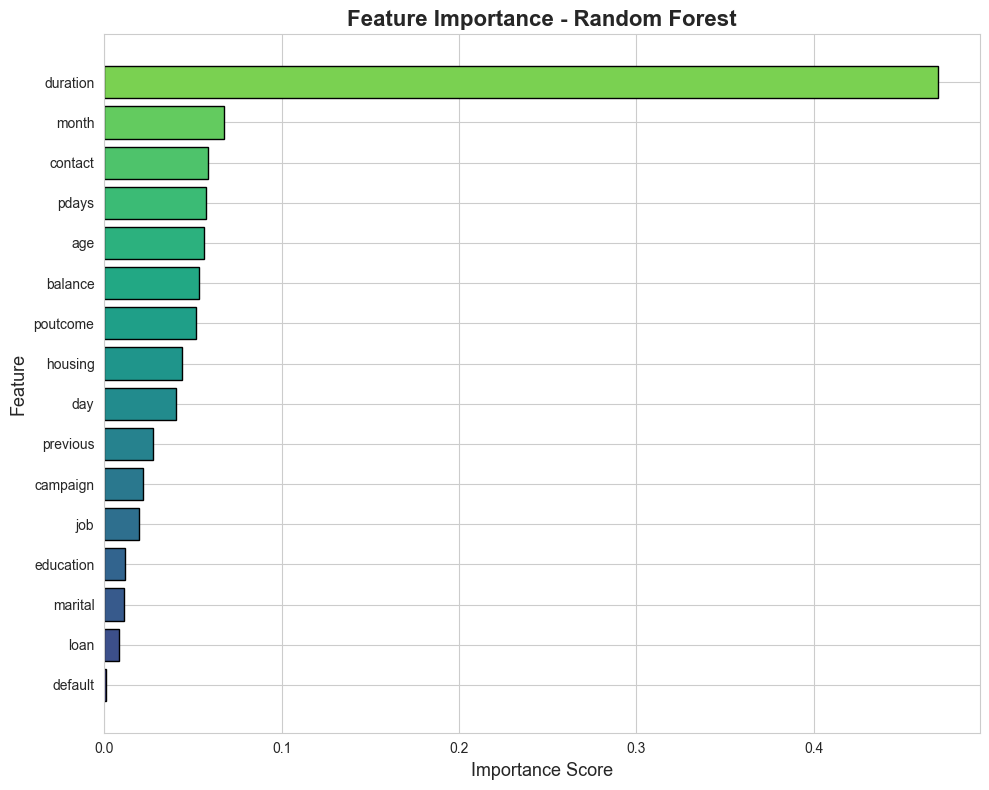

Top 5 Most Important Features:
----------------------------------------
  1. age: 0.0564
  2. pdays: 0.0573
  3. contact: 0.0587
  4. month: 0.0676
  5. duration: 0.4701


In [28]:
# ============================================================
# Step 21: Feature Importance - Random Forest
# ============================================================

feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))

colors = plt.cm.viridis(
    np.linspace(0.2, 0.8, len(feature_imp))
)
plt.barh(feature_imp['Feature'],
         feature_imp['Importance'],
         color=colors, edgecolor='black')

plt.title('Feature Importance - Random Forest',
          fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features:")
print("-" * 40)
for rank, (_, row) in enumerate(
        feature_imp.tail(5).iterrows(), 1):
    print(f"  {rank}. {row['Feature']}: {row['Importance']:.4f}")

In [29]:
# ============================================================
# Step 22: SHAP - Explainable AI
# ============================================================

print("Calculating SHAP values... (this may take a moment)")

# Create SHAP explainer using Random Forest
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for test set (first 100 samples)
X_test_sample = X_test.iloc[:100]
shap_values = explainer.shap_values(X_test_sample)

# Fix: Check shap_values shape and select correctly
print(f"SHAP values type: {type(shap_values)}")

if isinstance(shap_values, list):
    print(f"Number of classes: {len(shap_values)}")
    print(f"Shape of shap_values[0]: {shap_values[0].shape}")
    print(f"Shape of shap_values[1]: {shap_values[1].shape}")
    # Use index 1 for positive class (subscribed)
    shap_vals_to_use = shap_values[1]
else:
    print(f"Shape of shap_values: {shap_values.shape}")
    shap_vals_to_use = shap_values

print(f"X_test_sample shape: {X_test_sample.shape}")
print(f"SHAP values shape to use: {shap_vals_to_use.shape}")
print("SHAP values calculated successfully!")

Calculating SHAP values... (this may take a moment)
SHAP values type: <class 'numpy.ndarray'>
Shape of shap_values: (100, 16, 2)
X_test_sample shape: (100, 16)
SHAP values shape to use: (100, 16, 2)
SHAP values calculated successfully!


<Figure size 1200x800 with 0 Axes>

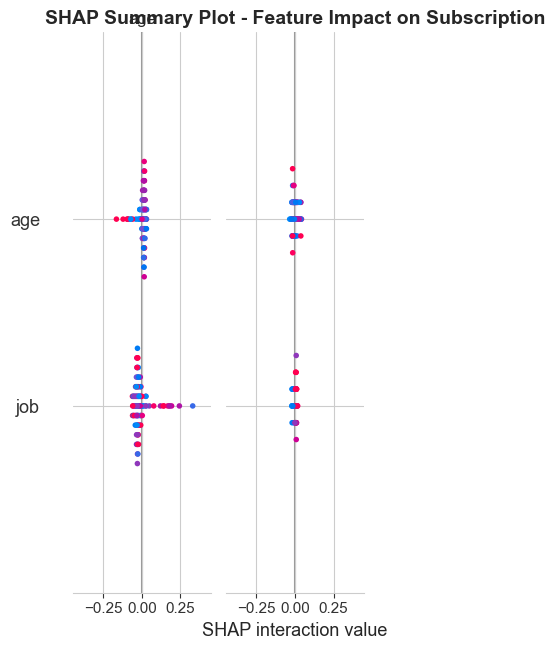

How to read SHAP Summary Plot:
  - Features ranked by importance (top = most important)
  - Red dots = high feature value
  - Blue dots = low feature value
  - Right side = increases subscription chance
  - Left side = decreases subscription chance


In [30]:
# ============================================================
# Step 23: SHAP Summary Plot
# ============================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_vals_to_use,        # Fixed variable
    X_test_sample,
    feature_names=X.columns.tolist(),
    show=False
)

plt.title('SHAP Summary Plot - Feature Impact on Subscription',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("How to read SHAP Summary Plot:")
print("  - Features ranked by importance (top = most important)")
print("  - Red dots = high feature value")
print("  - Blue dots = low feature value")
print("  - Right side = increases subscription chance")
print("  - Left side = decreases subscription chance")

<Figure size 1000x700 with 0 Axes>

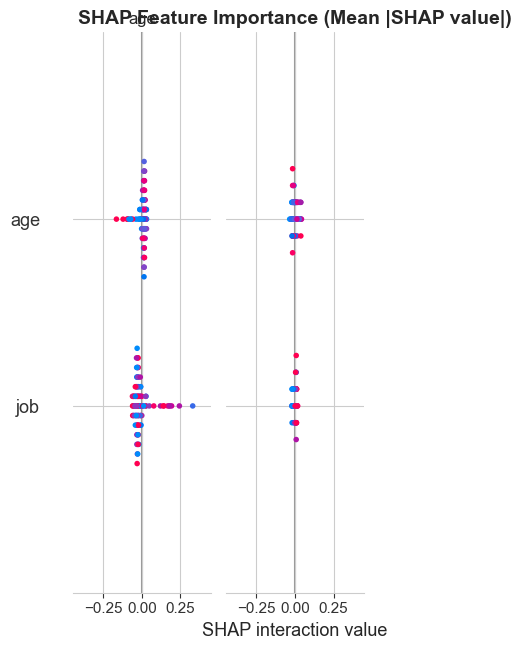

In [31]:
# ============================================================
# Step 24: SHAP Bar Plot
# ============================================================

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_vals_to_use,        # Fixed variable
    X_test_sample,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    show=False
)

plt.title('SHAP Feature Importance (Mean |SHAP value|)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# Step 25: SHAP - Explain 5 Individual Predictions
# ============================================================

print("=" * 60)
print("EXPLAINING 5 INDIVIDUAL PREDICTIONS USING SHAP")
print("=" * 60)

feature_names = X.columns.tolist()

for i in range(5):
    actual = y_test.iloc[i]
    predicted = rf_pred[i]
    probability = rf_prob[i]

    print(f"\nCustomer {i+1}:")
    print(f"  Actual: {'Subscribed' if actual == 1 else 'Not Subscribed'}")
    print(f"  Predicted: {'Subscribed' if predicted == 1 else 'Not Subscribed'}")
    print(f"  Subscription Probability: {probability:.2%}")
    print(f"  Result: {'CORRECT' if actual == predicted else 'INCORRECT'}")

    # Fix: Flatten shap values to 1D array
    customer_shap = np.array(shap_vals_to_use[i]).flatten()
    customer_features = np.array(
        X_test_sample.iloc[i].values
    ).flatten()

    # Make sure lengths match
    min_len = min(len(feature_names), 
                  len(customer_shap), 
                  len(customer_features))

    shap_df = pd.DataFrame({
        'Feature': feature_names[:min_len],
        'SHAP Value': customer_shap[:min_len],
        'Feature Value': customer_features[:min_len]
    }).sort_values('SHAP Value', key=abs, ascending=False)

    print(f"  Top 3 Influencing Features:")
    for _, row in shap_df.head(3).iterrows():
        direction = "INCREASES" if row['SHAP Value'] > 0 else "DECREASES"
        print(f"    - {row['Feature']} = {row['Feature Value']:.2f} "
              f"({direction} subscription chance, "
              f"SHAP: {row['SHAP Value']:.4f})")
    print("-" * 60)

EXPLAINING 5 INDIVIDUAL PREDICTIONS USING SHAP

Customer 1:
  Actual: Not Subscribed
  Predicted: Subscribed
  Subscription Probability: 66.68%
  Result: INCORRECT
  Top 3 Influencing Features:
    - pdays = -0.48 (INCREASES subscription chance, SHAP: 0.0390)
    - campaign = -0.19 (DECREASES subscription chance, SHAP: -0.0390)
    - job = -0.15 (DECREASES subscription chance, SHAP: -0.0141)
------------------------------------------------------------

Customer 2:
  Actual: Subscribed
  Predicted: Subscribed
  Subscription Probability: 75.09%
  Result: CORRECT
  Top 3 Influencing Features:
    - pdays = -0.48 (INCREASES subscription chance, SHAP: 0.0358)
    - campaign = -0.55 (DECREASES subscription chance, SHAP: -0.0358)
    - age = -0.44 (INCREASES subscription chance, SHAP: 0.0187)
------------------------------------------------------------

Customer 3:
  Actual: Not Subscribed
  Predicted: Not Subscribed
  Subscription Probability: 47.33%
  Result: CORRECT
  Top 3 Influencing Fea

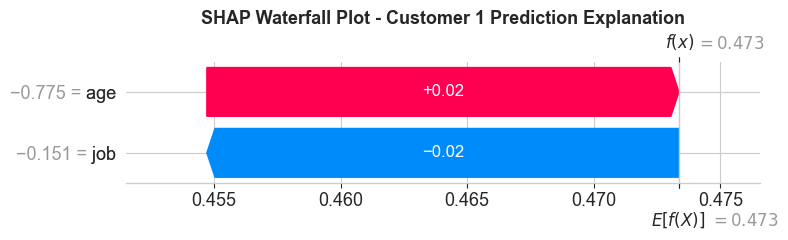

In [34]:
# ============================================================
# Step 26: SHAP Waterfall Plot for Customer 1
# ============================================================
# Waterfall plot shows step by step how each feature
# contributed to the final prediction

plt.figure(figsize=(12, 7))

# Get expected value and shap values for first customer
expected_value = explainer.expected_value[1]
customer_shap_values = shap_values[1][0]
customer_features = X_test_sample.iloc[0]

shap.waterfall_plot(
    shap.Explanation(
        values=customer_shap_values,
        base_values=expected_value,
        data=customer_features.values,
        feature_names=customer_features.index.tolist()
    ),
    show=False
)

plt.title('SHAP Waterfall Plot - Customer 1 Prediction Explanation',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

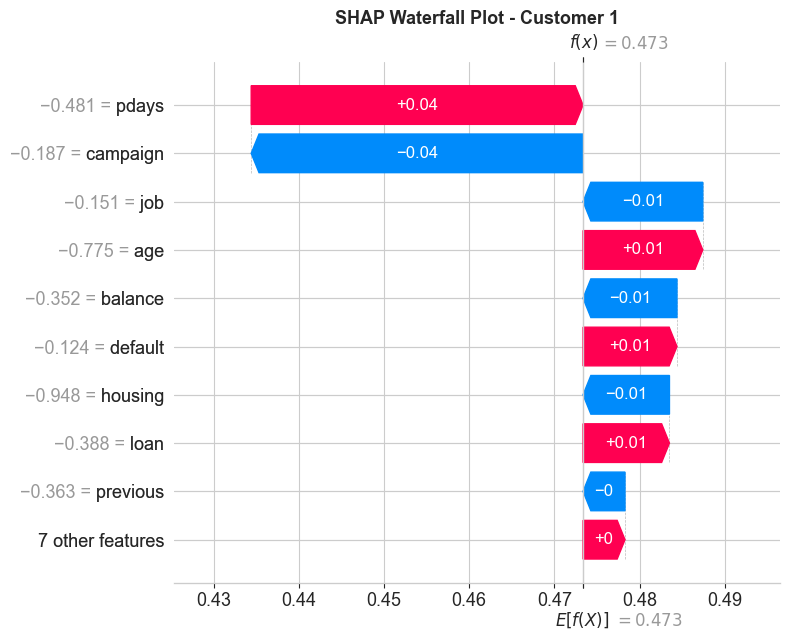

Waterfall plot complete!
How to read:
  - Red bars = features that INCREASE subscription chance
  - Blue bars = features that DECREASE subscription chance
  - E[f(x)] = average model prediction (starting point)
  - f(x) = final prediction for this customer


In [36]:
# ============================================================
# Step 26: SHAP Waterfall Plot for Customer 1
# ============================================================

# Get expected value
expected_value = explainer.expected_value

# Handle both list and single value cases
if isinstance(expected_value, (list, np.ndarray)):
    base_val = float(expected_value[1])
else:
    base_val = float(expected_value)

# Fix: Flatten shap values to 1D
customer_shap_vals = np.array(shap_vals_to_use[0]).flatten()
customer_data = np.array(X_test_sample.iloc[0].values).flatten()
feature_names_list = X_test_sample.columns.tolist()

# Make sure all arrays have same length
min_len = min(len(customer_shap_vals),
              len(customer_data),
              len(feature_names_list))

# Create explanation object with 1D values
explanation = shap.Explanation(
    values=customer_shap_vals[:min_len],
    base_values=base_val,
    data=customer_data[:min_len],
    feature_names=feature_names_list[:min_len]
)

# Plot waterfall
plt.figure(figsize=(12, 7))
shap.plots.waterfall(explanation, show=False)
plt.title('SHAP Waterfall Plot - Customer 1',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Waterfall plot complete!")
print("How to read:")
print("  - Red bars = features that INCREASE subscription chance")
print("  - Blue bars = features that DECREASE subscription chance")
print("  - E[f(x)] = average model prediction (starting point)")
print("  - f(x) = final prediction for this customer")